# Installing Keras

In [ ]:
!pip install tensorflow
!pip install matplotlib
!pip install pydot

In [ ]:
# If you have a GPU
# =====================================================================
# conda create -n Module4 python=3.11 anaconda
# conda activate Module4
# conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1.0
# pip install tensorflow==2.10.1
    # Anything above 2.10 is not supported on the GPU on Windows Native

In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

In [ ]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

## Import the Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

In [ ]:
import tensorflow as tf
print(tf.__version__)

## Getting the Dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)                                        # (60000, 28, 28)
print(y_train.shape)                                        # (60000,)

print(X_test.shape)                                         # (10000, 28, 28)
print(y_test.shape)                                         # (10000,)

print(X_train[0])
print(y_train[0])

In [ ]:
# format the data clearly to see the digit
# get the rows and columns of the data
rows    = X_train[0].shape[0]
columns = X_train[0].shape[1]

# used to store all the numbers of the digits
lines = ''
for r in range(rows):
    lines += ','.join([f'{i}'.ljust(3) for i in X_train[0][r]]) + "\n"
print(lines)

## Visualizing the Dataset

In [ ]:
# show the first 5 images in the training set
for index in range(5):
    plt.imshow(X_train[index])
    plt.colorbar()
    plt.grid(True)
    plt.xlabel(y_train[index])
    plt.show()

## Reshaping the Data

In [ ]:
RESHAPED = 784                                                 # 28x28 = 784

# training set 
X_train = X_train.reshape(60000, RESHAPED)
X_train = X_train.astype('float32')
print(X_train.shape)                                           # (60000, 784)

# test set
X_test = X_test.reshape(10000, RESHAPED)
X_test = X_test.astype('float32')
print(X_test.shape)                                            # (10000, 784)

## Normalizing the Data

In [ ]:
# normalize (convert to greyscale)
X_train /= 255
X_test /= 255

print(X_train[0])

## One-Hot Encoding

In [ ]:
NB_CLASSES = 10                           # number of outputs = number of digits

# convert class vectors to binary class matrices - one-hot encoding
Y_train = to_categorical(y_train, NB_CLASSES)
Y_test = to_categorical(y_test, NB_CLASSES)

# label for first row in training set
print(y_train[0])

# label (one-hot encoded) for first row in training set
print(Y_train[0])

# second row
print(y_train[1])     # label
print(Y_train[1])     # one-hot encoded

# third row
print(y_train[2])     # label
print(Y_train[2])     # one-hot encoded

## Building the Model

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
DROPOUT = 0.2

model = Sequential()
model.add(Input(shape=(RESHAPED,)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(DROPOUT))
model.add(Dense(64, activation='relu'))
model.add(Dropout(DROPOUT))
model.add(Dense(NB_CLASSES, activation='softmax'))

model.summary()

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

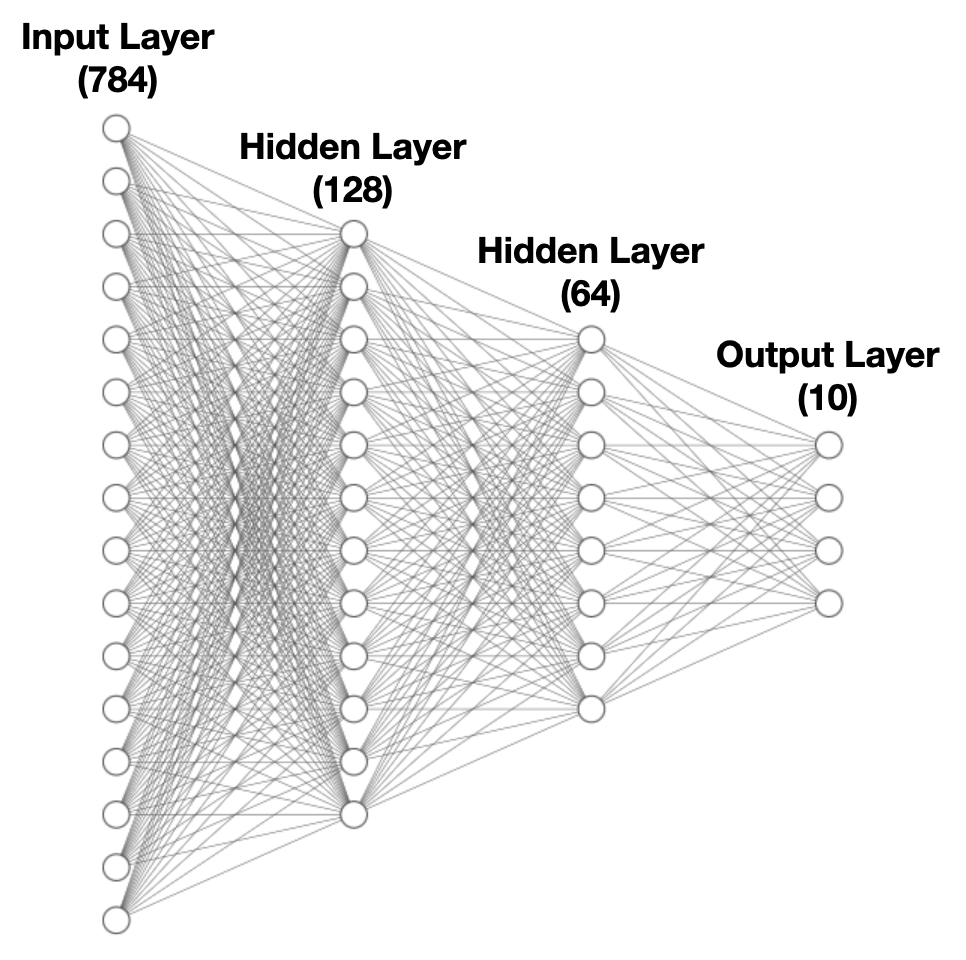

In [ ]:
# find out how many layers the model has
len(model.layers)

In [ ]:
# count only trainable parameters
len([layer for layer in model.layers if layer.count_params() > 0])

## Compiling the Model

In [ ]:
from tensorflow.keras.optimizers import SGD, RMSprop, Adam 

model.compile(loss='categorical_crossentropy',
              optimizer=SGD(),       # optimizer=RMSprop(),
              metrics=['accuracy'])  # either: accuracy, recall, or precision

## Training the Model

In [ ]:
NB_EPOCH         = 200
BATCH_SIZE       = 128         # number of training instances observed before 
                               # the optimizer performs a weight update
VERBOSE          = 1
VALIDATION_SPLIT = 0.2         # how much TRAIN is reserved for VALIDATION

history = model.fit(X_train, Y_train,
                    batch_size = BATCH_SIZE, 
                    epochs = NB_EPOCH,
                    verbose = VERBOSE, 
                    validation_split = VALIDATION_SPLIT)

## Evaluating the Model

In [ ]:
# score the model using the test set
score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("\nLoss value:", score[0])
print('Test accuracy:', score[1])

## Plotting the Training Accuracy and Validation Accuracy Chart

In [ ]:
# list all data in history
print(history.history.keys())
'''
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])
'''

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Plotting the Training Loss and Validation Loss Chart

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Performing Predictions

In [ ]:
# try out using a digit from the test set
import random

#=========
index = random.randint(0, 9999)
#=========

# shape of X_test
print(X_test.shape)                  # (10000, 784)

# shape of the first item in X_test  # (784,)
print(X_test[index].shape)

# in order to do prediction, you need to send in a 2-d array of shape (1,784)
x = X_test[index].reshape(-1,784)
print(x.shape)                       # (1,784)
# print(x)

# show the number
plt.imshow(X_test[index].reshape(28,28), interpolation='none')
plt.title("Digit: {}".format(y_test[index]))

In [ ]:
# you can do the prediction now
print(model.predict(x))

In [ ]:
# the predict_classes() is deprecated
# print(model.predict_classes(x))       

# see the original value
print(Y_test[index])

In [ ]:
#---updated---
print(np.argmax(model.predict(x), axis=-1))

# see the original value
print(Y_test[index])

## Saving the Trained Model

In [ ]:
# creates a HDF5 file 'my_model.keras'
model.save('my_model.keras')          
  
# deletes the existing model
del model

## Loading the Trained Model

In [ ]:
from tensorflow.keras.models import load_model

# returns a compiled model identical to the previous one
import numpy as np
model = load_model('my_model.keras')

In [ ]:
print(np.argmax(model.predict(x), axis=-1))

# Using PyTorch

In [ ]:
!pip install torch
!pip install torchsummary

## Simple Model

In [ ]:
import torch
import torch.nn as nn

# Parameters
RESHAPED = 784     # example input size (e.g., 28x28 flattened image)
NB_CLASSES = 10     # number of output classes

# Define model
class SimpleModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(input_size, num_classes)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.fc(x)          # Passes the input x through the fully connected layer. Produces raw scores (logits) for each class.
        x = self.softmax(x)     # Converts logits into probabilities. Each row of x now sums to 1 (so it can be interpreted as class probabilities).
        return x
        
# =================
# # alternative way
# class SimpleModel(nn.Module):
#     def __init__(self, input_size, num_classes):
#         super(SimpleModel, self).__init__()
#         self.layers = nn.Sequential(
#             nn.Linear(input_size, num_classes),
#             nn.Softmax(dim=1)
#         )
        
#     def forward(self, x):
#         return self.layers(x)   # sends x through all the layers in the Sequential container
# =================

# Create model instance
model = SimpleModel(input_size=RESHAPED, num_classes=NB_CLASSES)

# Print model summary
print(model)

The ```forward()``` method defines how data flows through the model during a forward pass

In [ ]:
from torchsummary import summary
summary(model, (RESHAPED,))

## Multi-layer Model

In [ ]:
import torch
import torch.nn as nn

# Parameters
RESHAPED = 784    # example input size
NB_CLASSES = 10   # number of output classes

# Define model
class MultiLayerModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MultiLayerModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
            nn.Softmax(dim=1)   # softmax over class dimension
        )
    
    def forward(self, x):
        return self.layers(x)

# Create model instance
model = MultiLayerModel(input_size=RESHAPED, num_classes=NB_CLASSES)

# Print model architecture
print(model)

## Model with dropouts

In [ ]:
import torch
import torch.nn as nn

# Parameters
RESHAPED = 784    # example input size
NB_CLASSES = 10   # number of output classes
DROPOUT = 0.2     # dropout rate

# Define model
class DropoutModel(nn.Module):
    def __init__(self, input_size, num_classes, dropout_rate):
        super(DropoutModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, num_classes),
            nn.Softmax(dim=1)   # softmax over class dimension
        )
    
    def forward(self, x):
        return self.layers(x)

# Create model instance
model = DropoutModel(input_size=RESHAPED, num_classes=NB_CLASSES, dropout_rate=DROPOUT)

# Print model architecture
print(model)

## Training the model

In [ ]:
!pip install torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Parameters
RESHAPED = 28*28      # 28x28 images flattened
NB_CLASSES = 10
DROPOUT = 0.2
BATCH_SIZE = 64
EPOCHS = 3  # short example

# Transform: convert to tensor and flatten
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 to 784
])

# Load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()  # expects raw logits
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop (simplified)
model.train()
for epoch in range(EPOCHS):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Making predictions on test set
model.eval()

## Predictions using test set

In [ ]:
with torch.no_grad():
    sample_data, sample_target = next(iter(test_loader))  # get one batch
    outputs = model(sample_data)
    predicted_classes = torch.argmax(outputs, dim=1)

print("Predicted classes for first batch:")
print(predicted_classes)
print("Actual classes for first batch:")
print(sample_target)

## Predicting with probablities

In [ ]:
# Make predictions with probabilities
model.eval()
with torch.no_grad():
    sample_data, sample_target = next(iter(test_loader))
    probabilities = model(sample_data)           # shape: [batch_size, NB_CLASSES]
    predicted_classes = torch.argmax(probabilities, dim=1)

print("Predicted probabilities for first sample:")
print(probabilities[0])
print("Predicted class for first sample:", predicted_classes[0])
print("Actual class for first sample:", sample_target[0])

## Visualizing the image

In [ ]:
import matplotlib.pyplot as plt

# Pick the first sample from the test batch
sample_image = sample_data[0].view(28, 28)  # reshape to 28x28 for visualization
sample_probs = probabilities[0].numpy()     # convert to numpy array
predicted_class = predicted_classes[0].item()
actual_class = sample_target[0].item()

# Plot the image
plt.figure(figsize=(6,3))

plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap='gray')
plt.title(f"Label: {actual_class}\nPredicted: {predicted_class}")
plt.axis('off')

# Plot the probabilities as a bar chart
plt.subplot(1, 2, 2)
plt.bar(range(NB_CLASSES), sample_probs, color='skyblue')
plt.xticks(range(NB_CLASSES))
plt.xlabel('Digit')
plt.ylabel('Probability')
plt.title('Predicted Probabilities')

plt.tight_layout()
plt.show()